## Reproduce Machiel speleo01 test

## Load records

In [ ]:
## Import libraries
import pyleoclim as pyleo
import pandas as pd
din2 = pd.read_table('../data/GDD1_d18O_CopraSpline_2mm.txt')
ts_din2 = pyleo.Series(
    time =  din2.iloc[:, 0] , 
    value = din2.iloc[:, 1],
    time_name = 'Age',
    time_unit = 'Years BP',
    value_name = 'd18O',
    value_unit = 'VPDB',
    label = 'Dino cave-2mm', verbose=False)


din5 = pd.read_table('../data/GDD1_d18O_CopraSpline_5mm.txt')
ts_din5 = pyleo.Series(
    time =  din5.iloc[:, 0] , 
    value = din5.iloc[:, 1],
    time_name = 'Age',
    time_unit = 'Years BP',
    value_name = 'd18O',
    value_unit = 'VPDB',
    label = 'Dino cave-5mm', verbose=False)


## Santiago cave, Ecuador
sant = pd.read_table('../data/santiago2012.txt', comment='#')
sant.head()
ts_sant = pyleo.Series(
    time=sant["age_calBP"],
    value=sant["d18OcarbVPDB"],
    time_name="Age",
    time_unit="years BP",
    value_name="d18O",
    value_unit="per mil",
    label="Santiago Cave")




## Tangga cave, Indonesia 2024.03.16
tang = pd.read_table(r'../data/tangga2018d18o.txt', comment='#')
tang.head()

ts_tang = pyleo.Series(
    time=tang["age_calkaBP"]*1000,
    value=tang["d18O-raw"],
    time_name="Age",
    time_unit="years BP",
    value_name="d18O",
    value_unit="per mil",
    label="Tangga Cave")




Time axis values sorted in ascending order
NaNs have been detected and dropped.
Time axis values sorted in ascending order
NaNs have been detected and dropped.
Time axis values sorted in ascending order
NaNs have been detected and dropped.
Time axis values sorted in ascending order
Time axis values sorted in ascending order


Python Code to Perform the Z-Test:

In [1]:
import scipy.stats as stats

# Trend and standard deviation for GGM (Power Law Model)
trend_ggm = -1.2423133807959876e-05
trend_sigma_ggm = 2.3857168174127102e-05

# Trend and standard deviation for AR1 model
trend_ar1 = -9.983147931132861e-06
trend_sigma_ar1 = 4.0353205218282385e-06

# Function to compute Z-score and p-value
def compute_significance(trend, trend_sigma):
    z_score = trend / trend_sigma
    p_value = 2 * (1 - stats.norm.cdf(abs(z_score)))  # two-tailed test
    return z_score, p_value

# Calculate for GGM model
z_score_ggm, p_value_ggm = compute_significance(trend_ggm, trend_sigma_ggm)

# Calculate for AR1 model
z_score_ar1, p_value_ar1 = compute_significance(trend_ar1, trend_sigma_ar1)

# Display results
print(f"GGM Model: Z-Score = {z_score_ggm}, P-Value = {p_value_ggm}")
print(f"AR1 Model: Z-Score = {z_score_ar1}, P-Value = {p_value_ar1}")


GGM Model: Z-Score = -0.5207296070215349, P-Value = 0.6025551464244341
AR1 Model: Z-Score = -2.4739417543491453, P-Value = 0.013363148126231517


Python Code to Fit Nonparametric Trend and Assess Significance

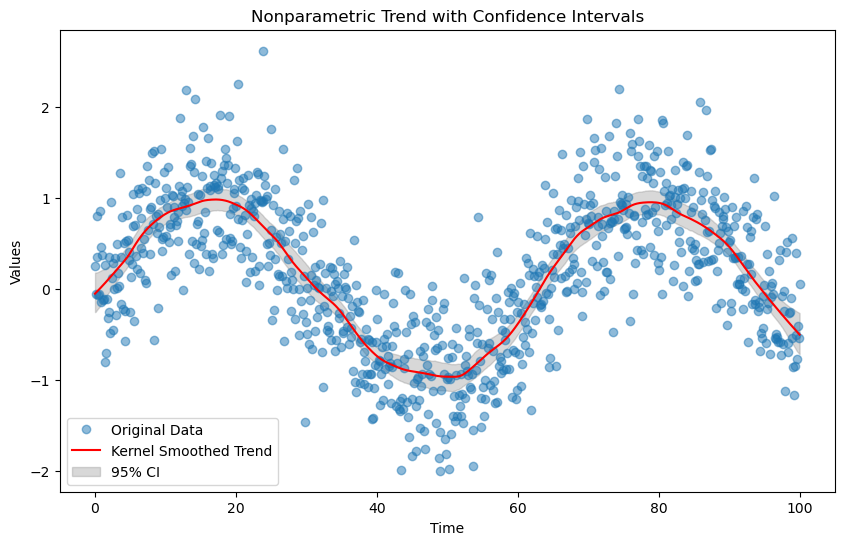

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.utils import resample
from statsmodels.nonparametric.smoothers_lowess import lowess

# Sample data (replace this with your actual time series data)
np.random.seed(42)
time = np.linspace(0, 100, 880)  # Example time data (880 points)
values = np.random.randn(880) * 0.5 + np.sin(time / 10)  # Example values with a trend

# 1. Fit Nonparametric Trend Using LOESS (or LOWESS - locally weighted scatterplot smoothing)
smoothed_values = lowess(values, time, frac=0.1)  # frac is the smoothing parameter

# 2. Bootstrap Procedure to Assess Trend Significance
n_bootstrap = 1000  # Number of bootstrap resamples
bootstrap_trends = []

for i in range(n_bootstrap):
    # Resample data with replacement
    boot_time, boot_values = resample(time, values)
    
    # Fit trend to resampled data
    boot_smoothed = lowess(boot_values, boot_time, frac=0.1)
    
    # Store the smoothed trend for the resampled data
    bootstrap_trends.append(np.interp(time, boot_smoothed[:, 0], boot_smoothed[:, 1]))

# Convert to numpy array for easier manipulation
bootstrap_trends = np.array(bootstrap_trends)

# 3. Calculate Confidence Intervals
lower_bound = np.percentile(bootstrap_trends, 2.5, axis=0)  # 2.5th percentile
upper_bound = np.percentile(bootstrap_trends, 97.5, axis=0)  # 97.5th percentile

# 4. Plot the Original Trend with Confidence Intervals
plt.figure(figsize=(10, 6))
plt.plot(time, values, 'o', alpha=0.5, label='Original Data')
plt.plot(smoothed_values[:, 0], smoothed_values[:, 1], color='red', label='Kernel Smoothed Trend')

# Plot confidence intervals
plt.fill_between(time, lower_bound, upper_bound, color='gray', alpha=0.3, label='95% CI')

plt.legend()
plt.xlabel('Time')
plt.ylabel('Values')
plt.title('Nonparametric Trend with Confidence Intervals')
plt.show()

# 5. Significance Assessment
# If the observed trend falls consistently outside the confidence interval generated
# by the bootstrapped trends, it is likely significant.


Python Example for Computing PSD and Fitting Noise Models

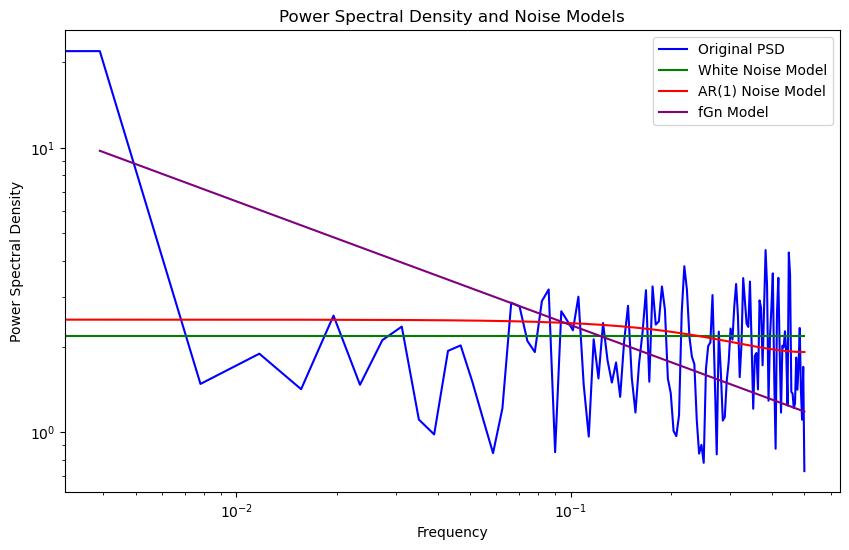

White Noise sigma: [1.4780058]
AR(1) sigma: 1.4743276089410893, alpha: 0.06550239523623594
fGn sigma: 0.9351989362362195, Hurst exponent: 0.21757276645377738


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.optimize import curve_fit

# Generate example data (replace this with your real time series)
np.random.seed(42)
n_points = 880
time = np.linspace(0, 100, n_points)
values = np.random.randn(n_points) + np.sin(time/10)  # Sample data with trend and noise

# 1. Compute Power Spectral Density (PSD) using Welch's method
frequencies, psd = signal.welch(values, fs=1.0, nperseg=256)

# 2. Define theoretical noise models for comparison

# White noise model: Flat PSD
def white_noise_psd(frequencies, sigma):
    return sigma**2 * np.ones_like(frequencies)

# AR(1) model: Red noise (power concentrated at low frequencies)
def ar1_psd(frequencies, sigma, alpha):
    return sigma**2 / (1 - 2 * alpha * np.cos(2 * np.pi * frequencies) + alpha**2)

# Fractional Gaussian noise (fGn) model (approximation)
def fgn_psd(frequencies, sigma, H):
    return sigma**2 * (frequencies**(-2 * H))

# 3. Fit the PSD to different noise models

# White noise fit
popt_white, _ = curve_fit(white_noise_psd, frequencies, psd)
psd_white_fit = white_noise_psd(frequencies, *popt_white)

# AR1 noise fit
popt_ar1, _ = curve_fit(ar1_psd, frequencies, psd, bounds=(0, [np.inf, 1]))
psd_ar1_fit = ar1_psd(frequencies, *popt_ar1)

# fGn noise fit (assuming Hurst exponent in reasonable range)
popt_fgn, _ = curve_fit(fgn_psd, frequencies[frequencies > 0], psd[frequencies > 0], bounds=(0, [np.inf, 1]))
psd_fgn_fit = fgn_psd(frequencies[frequencies > 0], *popt_fgn)

# 4. Plot the original PSD and the fitted noise models
plt.figure(figsize=(10, 6))
plt.loglog(frequencies, psd, label='Original PSD', color='blue')
plt.loglog(frequencies, psd_white_fit, label='White Noise Model', color='green')
plt.loglog(frequencies, psd_ar1_fit, label='AR(1) Noise Model', color='red')
plt.loglog(frequencies[frequencies > 0], psd_fgn_fit, label='fGn Model', color='purple')

plt.xlabel('Frequency')
plt.ylabel('Power Spectral Density')
plt.title('Power Spectral Density and Noise Models')
plt.legend()
plt.show()

# 5. Use the fitted parameters to infer the best noise model
print(f'White Noise sigma: {popt_white}')
print(f'AR(1) sigma: {popt_ar1[0]}, alpha: {popt_ar1[1]}')
print(f'fGn sigma: {popt_fgn[0]}, Hurst exponent: {popt_fgn[1]}')



(<Figure size 1000x400 with 1 Axes>,
 <Axes: xlabel='Age [Years BP]', ylabel='d18O [VPDB]'>)

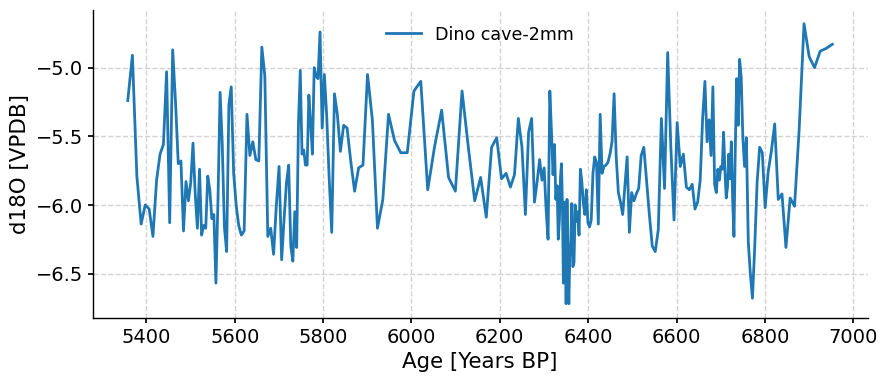

In [4]:
ts_din2.plot()

Time axis values sorted in ascending order


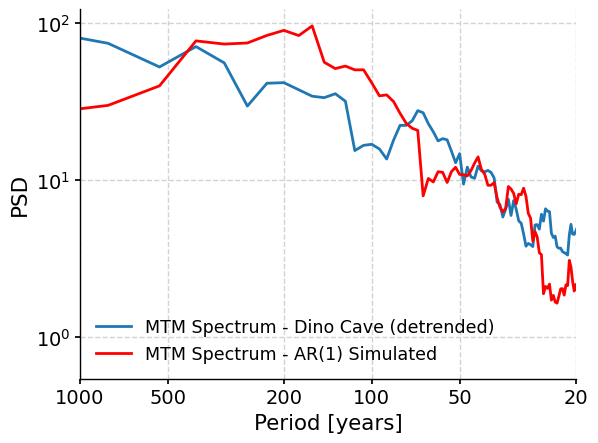

In [9]:
import pyleoclim as pyleo
import matplotlib.pyplot as plt

# Step 1: Interpolate and detrend the series
ts_din2_clean = ts_din2.interp().detrend()

# Step 2: Estimate AR(1) persistence (tau) from the data
tau = pyleo.utils.tsmodel.tau_estimation(ts_din2_clean.value, ts_din2_clean.time)

# Step 3: Simulate AR(1) process using the fitted tau
ar1_simulated = pyleo.utils.tsmodel.ar1_model(ts_din2_clean.time, tau)

# Step 4: Perform MTM spectral analysis on the detrended data
mtm_spectrum = ts_din2_clean.spectral(method='mtm')  # No 'nw' parameter

# Step 5: Perform MTM spectral analysis on the simulated AR(1) data to compare
ts_ar1_sim = pyleo.Series(time=ts_din2_clean.time, value=ar1_simulated)
ar1_mtm_spectrum = ts_ar1_sim.spectral(method='mtm')

# Step 6: Plot the results
fig, ax = plt.subplots()
mtm_spectrum.plot(ax=ax, label='MTM Spectrum - Dino Cave (detrended)')
ar1_mtm_spectrum.plot(ax=ax, label='MTM Spectrum - AR(1) Simulated', color='r')

plt.legend()
plt.show()



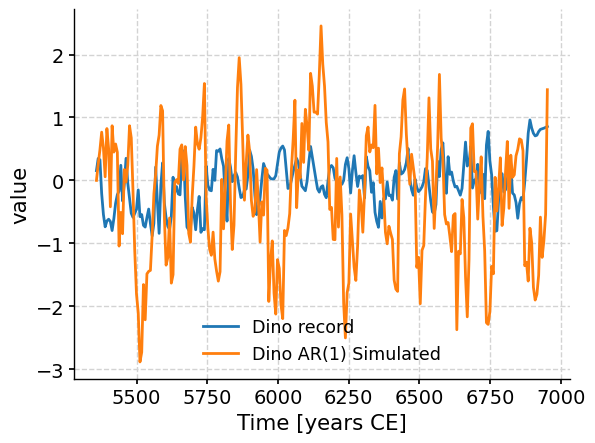

In [18]:
fig, ax = plt.subplots()
ts_din2.plot(ax=ax, label='Dino record')
ts_ar1_sim.plot(ax=ax, label='Dino AR(1) Simulated')
plt.legend()


## Calculate rho

### Dino 2mm

In [1]:
import numpy as np
import pyleoclim as pyleo

# Step 1: Estimate the tau value using the tau_estimation function on your time series
# Assuming you have already defined your time series ts_din2_clean (as detrended and interpolated)

# Get the time intervals (assuming ts_din2.time is in 'Years BP')
time_intervals = np.diff(ts_din2_clean.time)

# Calculate the average sampling interval Δt (mean of time differences)
mean_dt = np.mean(time_intervals)

# Step 2: Estimate the tau value (using the previous tau_estimation function or directly)
# Here, we use the tau_estimation function, assuming it has been defined as in the previous explanation
tau = pyleo.utils.tsmodel.tau_estimation(ts_din2_clean.value, ts_din2_clean.time)

# Step 3: Convert tau to rho using the formula
rho = np.exp(-mean_dt / tau)

print(f"Estimated persistence (tau): {tau}")
print(f"Autocorrelation parameter (rho): {rho}")



NameError: name 'ts_din2_clean' is not defined

### Dino 5mm

In [25]:
ts_din5_clean = ts_din5.interp().detrend()
tau = pyleo.utils.tsmodel.tau_estimation(ts_din5_clean.value, ts_din5_clean.time)

# Step 3: Convert tau to rho using the formula
rho = np.exp(-mean_dt / tau)

print(f"Estimated persistence (tau): {tau}")
print(f"Autocorrelation parameter (rho): {rho}")

Estimated persistence (tau): 35.069450692766864
Autocorrelation parameter (rho): 0.8389658326789922


### Santiago

In [27]:
ts_sant_clean = ts_sant.interp().detrend()
tau = pyleo.utils.tsmodel.tau_estimation(ts_sant_clean.value, ts_sant_clean.time)
rho = np.exp(-mean_dt / tau)
print(f"Estimated persistence (tau): {tau}")
print(f"Autocorrelation parameter (rho): {rho}")

Estimated persistence (tau): 2059.4824643836937
Autocorrelation parameter (rho): 0.9970145491775719


### Shatuca

In [30]:
ts_shatuca_clean = ts_shatuca.interp().detrend()
tau = pyleo.utils.tsmodel.tau_estimation(ts_shatuca_clean.value, ts_shatuca_clean.time)
rho = np.exp(-mean_dt / tau)
print(f"Estimated persistence (tau): {tau}")
print(f"Autocorrelation parameter (rho): {rho}")

Estimated persistence (tau): 36.313243604059736
Autocorrelation parameter (rho): 0.8440266662672831


### Pacupahuain

In [32]:
ts_pacupa_clean = ts_pacupa.interp().detrend()
tau = pyleo.utils.tsmodel.tau_estimation(ts_pacupa_clean.value, ts_pacupa_clean.time)
rho = np.exp(-mean_dt / tau)
print(f"Estimated persistence (tau): {tau}")
print(f"Autocorrelation parameter (rho): {rho}")

Estimated persistence (tau): 440.1070142727298
Autocorrelation parameter (rho): 0.9861060994774394


### Condor

In [33]:
ts_condor_clean = ts_condor.interp().detrend()
tau = pyleo.utils.tsmodel.tau_estimation(ts_condor_clean.value, ts_condor_clean.time)
rho = np.exp(-mean_dt / tau)
print(f"Estimated persistence (tau): {tau}")
print(f"Autocorrelation parameter (rho): {rho}")

Estimated persistence (tau): 616.7397211990734
Autocorrelation parameter (rho): 0.9900654329979732


### Tangga

In [34]:
ts_tang_clean = ts_tang.interp().detrend()
tau = pyleo.utils.tsmodel.tau_estimation(ts_tang_clean.value, ts_tang_clean.time)
rho = np.exp(-mean_dt / tau)
print(f"Estimated persistence (tau): {tau}")
print(f"Autocorrelation parameter (rho): {rho}")

Estimated persistence (tau): 249.632489524982
Autocorrelation parameter (rho): 0.9756347626652168


(<Figure size 1000x400 with 1 Axes>,
 <Axes: xlabel='Age [years BP]', ylabel='d18O [permil]'>)

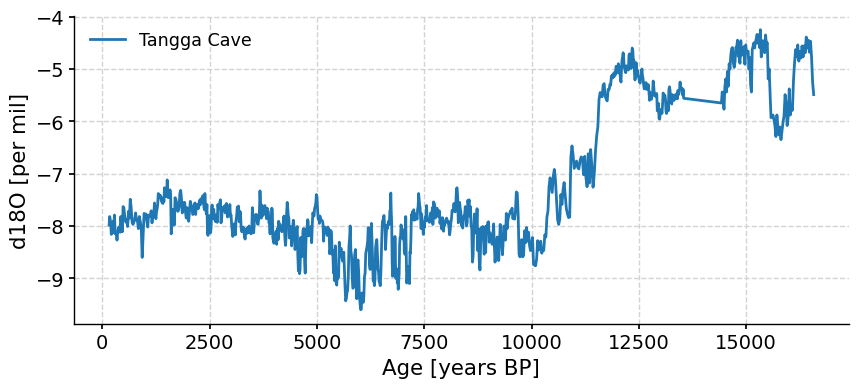

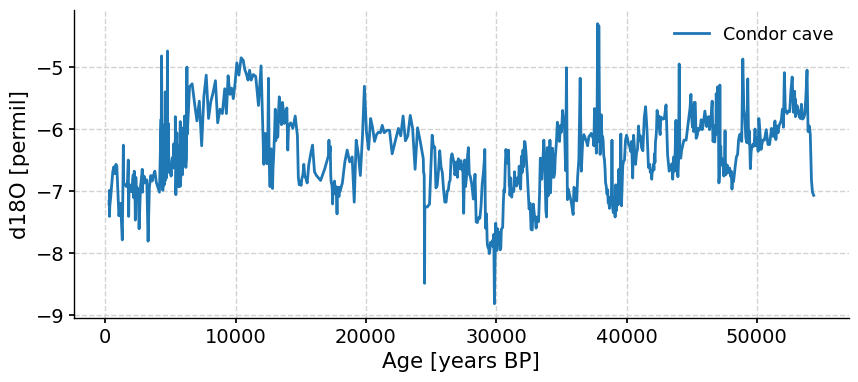

In [36]:
ts_tang.plot()
ts_condor.plot()